# Giai đoạn 2 — Chuẩn bị hồ sơ trúng tuyển (TTTH)

```
┌─────────────────────────────────────────────────────────────────────┐
│                            02_ChuanBiTTTH                           │
└─────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • data/raw/TTTH_THPT_Cleaned.xlsx     —  18.024 hồ sơ
    • 01_LamSachKhaoSat/mapping.json      —  bảng 39 ngành chuẩn
         │
         ▼
  XỬ LÝ
    1. Giữ hồ sơ TRÚNG TUYỂN (KQ = TT)
    2. Remap mã ngành đã đổi · loại mã không thuộc 39 ngành
    3. Loại tổ hợp D10 — khảo sát không có học sinh nào thi tổ hợp này
    4. Khử số báo danh trùng
    5. Trải M1/M2/M3 thành 10 cột điểm cùng lược đồ với khảo sát
         │
         ▼
  ĐẦU RA
    • 02_ChuanBiTTTH/ttth_sach.csv        —  hồ sơ dùng được
    • 02_ChuanBiTTTH/do_phu_theo_nganh.csv
    • 02_ChuanBiTTTH/hinh_2_*.png         —  4 hình
```

## Nguồn này đóng góp gì

Hồ sơ trúng tuyển có **điểm thi và tổ hợp CÓ THẬT** của hàng nghìn thí sinh đã đỗ vào từng ngành —
thứ mà 574 phiếu khảo sát không thể có nhiều. Đây là phần thông tin thật mà GA sẽ dựa vào.

Nhưng nó **không có** 10 câu Likert, không có giới tính, không có mục tiêu nghề nghiệp. Ba nhóm cột
đó sẽ do GA sinh ra ở Giai đoạn 6, học từ chính phiếu khảo sát của cùng ngành.

| | Khảo sát | TTTH |
|---|---|---|
| Ngành trúng tuyển | ✅ | ✅ |
| Tổ hợp xét tuyển | ✅ | ✅ |
| Điểm 3 môn | ✅ | ✅ |
| 10 câu Likert | ✅ | ❌ → GA sinh |
| Giới tính | ✅ | ❌ → GA sinh |
| Mục tiêu nghề nghiệp | ✅ | ❌ → GA sinh |

## Cột `DUT` — vì sao không dùng

`DUT` là điểm ưu tiên khu vực/đối tượng. Học sinh dùng web **không khai được** thông tin này, nên
đưa vào làm đặc trưng sẽ tạo ra mô hình chỉ chạy được trên dữ liệu tuyển sinh chứ không chạy được
trên người dùng thật. Bỏ.

## Tổ hợp D10 — vì sao loại

TTTH có 963 hồ sơ thi tổ hợp D10 (Toán, Địa, Anh), nhưng **không phiếu khảo sát nào** thi tổ hợp
này. Một dòng huấn luyện mang tổ hợp mà lúc phục vụ không bao giờ gặp thì vô dụng: nó tạo thêm một
cột one-hot luôn bằng 0 khi dự đoán thật.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_TachTrainTest",
    4: "04_MocChuan",
    5: "05_HocPhanPhoi",
    6: "06_GA_TangCuong",
    7: "07_KiemDinhGA",
    8: "08_TrainFinal",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

OUT = thu_muc(2)
M = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
MA_TO_TEN = {int(k): v for k, v in M["ma_to_ten"].items()}
NHOM = {int(k): v for k, v in M["nganh_to_nhom"].items()}
TEN_NHOM = {int(k): v for k, v in M["ten_nhom"].items()}
C_DIEM = M["cot_diem"]

# Mã ngành đã đổi theo quy chế tuyển sinh. Chỉ remap những mã ĐÃ XÁC MINH;
# mã không rõ thì loại bỏ, vì đoán sai mã ngành là làm hỏng nhãn huấn luyện.
REMAP = {7540110: 7540106}      # → Đảm bảo chất lượng và an toàn thực phẩm

# Tổ hợp → 3 môn, theo đúng thứ tự M1/M2/M3 trong quy chế
TO_HOP_MON = {
    "A00": ["Toan", "Ly", "Hoa"],     "A01": ["Toan", "Ly", "Anh"],
    "B00": ["Toan", "Hoa", "Sinh"],   "D01": ["Toan", "Van", "Anh"],
    "D07": ["Toan", "Hoa", "Anh"],    "D09": ["Toan", "Su", "Anh"],
    "D15": ["Van", "Dia", "Anh"],
}
BO_TO_HOP = ["D10"]               # khảo sát không có học sinh nào thi D10

tho = pd.read_excel(RAW / "TTTH_THPT_Cleaned.xlsx")
print(f"Đọc {len(tho):,} hồ sơ · cột: {list(tho.columns)}")
print(f"Kết quả: {tho.KQ.value_counts().to_dict()}")

Đọc 18,024 hồ sơ · cột: ['SBD', 'Mã ngành trúng tuyển', 'Mã tổ hợp trúng tuyển', 'DUT', 'M1', 'M2', 'M3', 'KQ']
Kết quả: {'TT': 17272, 'KTT': 752}


## 1. Phễu lọc

In [2]:
buoc = [("Hồ sơ trong file", len(tho))]
d = tho.copy()

d = d[d.KQ == "TT"].copy()
buoc.append(("Trúng tuyển (KQ = TT)", len(d)))

d["ma_nganh"] = d["Mã ngành trúng tuyển"].astype(int).replace(REMAP)
n_remap = int(tho["Mã ngành trúng tuyển"].isin(REMAP).sum())
print(f"Remap mã ngành cũ: {n_remap} hồ sơ  {REMAP}")

la = d.ma_nganh.isin(MA_TO_TEN)
if (~la).any():
    print("\nMã ngành KHÔNG thuộc 39 ngành — loại bỏ:")
    for ma, c in d.loc[~la, "ma_nganh"].value_counts().items():
        print(f"   {ma}: {c:5,d} hồ sơ")
    print(f"   → tổng {int((~la).sum()):,} hồ sơ ({(~la).mean():.1%})")
d = d[la].copy()
buoc.append(("Mã ngành hợp lệ", len(d)))

d["to_hop_thi"] = d["Mã tổ hợp trúng tuyển"].astype(str).str.strip()
n_d10 = int(d.to_hop_thi.isin(BO_TO_HOP).sum())
d = d[~d.to_hop_thi.isin(BO_TO_HOP)].copy()
print(f"\nLoại tổ hợp {BO_TO_HOP}: {n_d10:,} hồ sơ")
buoc.append((f"Bỏ tổ hợp {'/'.join(BO_TO_HOP)}", len(d)))

la_th = d.to_hop_thi.isin(TO_HOP_MON)
if (~la_th).any():
    print("Tổ hợp chưa có bảng môn:", d.loc[~la_th, "to_hop_thi"].value_counts().to_dict())
d = d[la_th].copy()
buoc.append(("Tổ hợp có bảng môn", len(d)))

n_trung = int(d.SBD.duplicated().sum())
d = d.drop_duplicates(subset="SBD", keep="first").copy()
print(f"\nSố báo danh trùng: {n_trung} → giữ bản đầu tiên")
buoc.append(("Khử SBD trùng", len(d)))

co_diem = d[["M1", "M2", "M3"]].notna().all(axis=1)
d = d[co_diem].reset_index(drop=True)
buoc.append(("Đủ 3 môn điểm", len(d)))

print()
for i, (ten, n) in enumerate(buoc):
    mat = f"  (−{buoc[i-1][1]-n:,})" if i else ""
    print(f"   {ten:<28} {n:>7,}{mat}")
print(f"\nCòn {len(d):,} hồ sơ · {d.ma_nganh.nunique()}/39 ngành")

Remap mã ngành cũ: 360 hồ sơ  {7540110: 7540106}

Mã ngành KHÔNG thuộc 39 ngành — loại bỏ:
   7720498:   213 hồ sơ
   7720499:   131 hồ sơ
   7510602:    18 hồ sơ
   7620303:     7 hồ sơ
   7520311:     4 hồ sơ
   → tổng 373 hồ sơ (2.2%)

Loại tổ hợp ['D10']: 963 hồ sơ

Số báo danh trùng: 240 → giữ bản đầu tiên

   Hồ sơ trong file              18,024
   Trúng tuyển (KQ = TT)         17,272  (−752)
   Mã ngành hợp lệ               16,899  (−373)
   Bỏ tổ hợp D10                 15,936  (−963)
   Tổ hợp có bảng môn            15,936  (−0)
   Khử SBD trùng                 15,696  (−240)
   Đủ 3 môn điểm                 15,696  (−0)

Còn 15,696 hồ sơ · 34/39 ngành


## 2. Trải M1/M2/M3 thành 10 cột điểm

File TTTH lưu điểm dưới dạng `M1`, `M2`, `M3` — *"môn thứ nhất, thứ hai, thứ ba của tổ hợp"*. Nhưng
`M1` của A00 là Toán còn `M1` của D15 là Văn. Để dùng chung một lược đồ với khảo sát, phải trải
chúng về đúng tên môn.

In [3]:
for c in C_DIEM:
    d[c] = np.nan
for th, mons in TO_HOP_MON.items():
    sel = d.to_hop_thi == th
    if not sel.any():
        continue
    for k, mon in enumerate(mons, start=1):
        d.loc[sel, f"diem_{mon}"] = d.loc[sel, f"M{k}"].values

so_mon = d[C_DIEM].notna().sum(axis=1)
assert (so_mon == 3).all(), f"phải đúng 3 môn/hồ sơ, đang có {so_mon.value_counts().to_dict()}"
print(f"Trải xong — mỗi hồ sơ đúng 3 môn có điểm, {len(C_DIEM)-3} môn để trống\n")

# ── Kiểm chứng: điểm TTTH có cùng thang với điểm khảo sát không? ──────────
ks = pd.read_csv(thu_muc(1) / "khaosat_sach.csv")
ss = []
for c in C_DIEM:
    a, b = d[c].dropna(), ks[c].dropna()
    if len(a) > 30 and len(b) > 10:
        ss.append({"mon": c.replace("diem_", ""), "ttth_n": len(a),
                   "ttth_tb": a.mean(), "ks_n": len(b), "ks_tb": b.mean(),
                   "chenh": a.mean() - b.mean()})
ss = pd.DataFrame(ss).sort_values("chenh")
print("SO ĐIỂM TRUNG BÌNH — TTTH so với khảo sát")
print(ss.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print(f"\nChênh lớn nhất {ss.chenh.abs().max():.2f} điểm — hai nguồn cùng thang 10,")
print("nên gộp chung vào một bảng huấn luyện là hợp lệ.")

Trải xong — mỗi hồ sơ đúng 3 môn có điểm, 7 môn để trống

SO ĐIỂM TRUNG BÌNH — TTTH so với khảo sát
 mon  ttth_n  ttth_tb  ks_n  ks_tb  chenh
 Dia     265     6.09    45   7.55  -1.46
 Van    6349     6.93   213   7.47  -0.54
  Su     114     7.45    59   7.71  -0.26
Sinh     798     7.05    64   7.18  -0.13
  Ly    7537     7.20   353   7.24  -0.04
Toan   15431     7.37   623   7.24   0.13
 Hoa    7349     7.40   333   7.19   0.20
 Anh    9245     7.37   328   6.96   0.41

Chênh lớn nhất 1.46 điểm — hai nguồn cùng thang 10,
nên gộp chung vào một bảng huấn luyện là hợp lệ.


   💾 hinh_2_1_pheu_loc.png


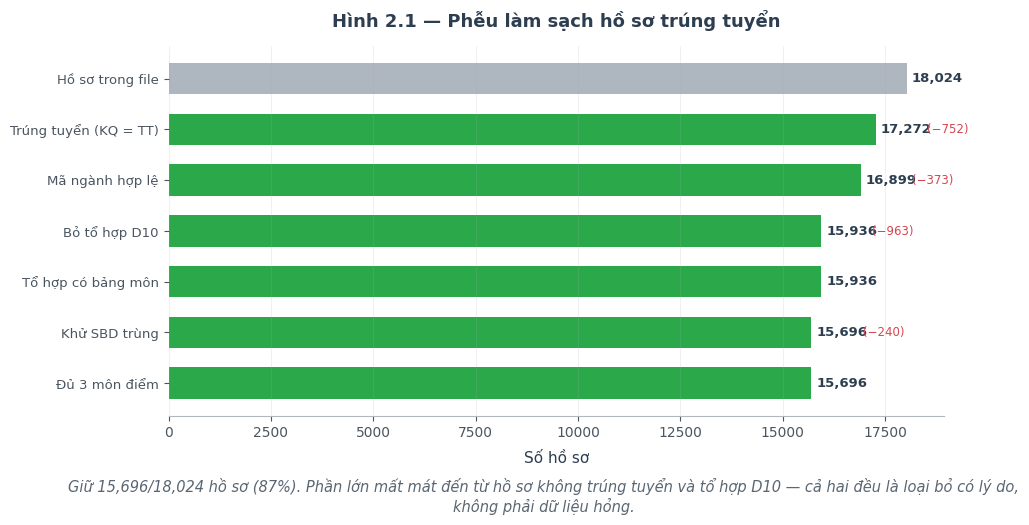

In [4]:
# ═══════════ HÌNH 2.1 — Phễu lọc TTTH ═══════════
fig, ax = plt.subplots(figsize=(10, 4.8))
ten = [b[0] for b in buoc]; sl = [b[1] for b in buoc]
ax.barh(range(len(buoc))[::-1], sl, color=[C_XAM] + [C_GA] * (len(buoc) - 1), height=.62)
ax.set_yticks(range(len(buoc))[::-1]); ax.set_yticklabels(ten, fontsize=9.5)
ax.set_xlabel("Số hồ sơ"); ax.set_title("Hình 2.1 — Phễu làm sạch hồ sơ trúng tuyển")
ax.grid(axis="y", alpha=0)
for i, n in enumerate(sl):
    ax.text(n + 120, len(buoc) - 1 - i, f"{n:,}", va="center", fontweight="bold", fontsize=9.5)
    if i and sl[i-1] != n:
        ax.text(n + 1250, len(buoc) - 1 - i, f"(−{sl[i-1]-n:,})", va="center",
                fontsize=8.5, color=C_THAT)
luu(fig, OUT, "hinh_2_1_pheu_loc.png",
    f"Giữ {sl[-1]:,}/{sl[0]:,} hồ sơ ({sl[-1]/sl[0]:.0%}). Phần lớn mất mát đến từ hồ sơ không "
    "trúng tuyển và tổ hợp D10 — cả hai đều là loại bỏ có lý do, không phải dữ liệu hỏng.")
plt.show()

   💾 hinh_2_2_do_phu.png


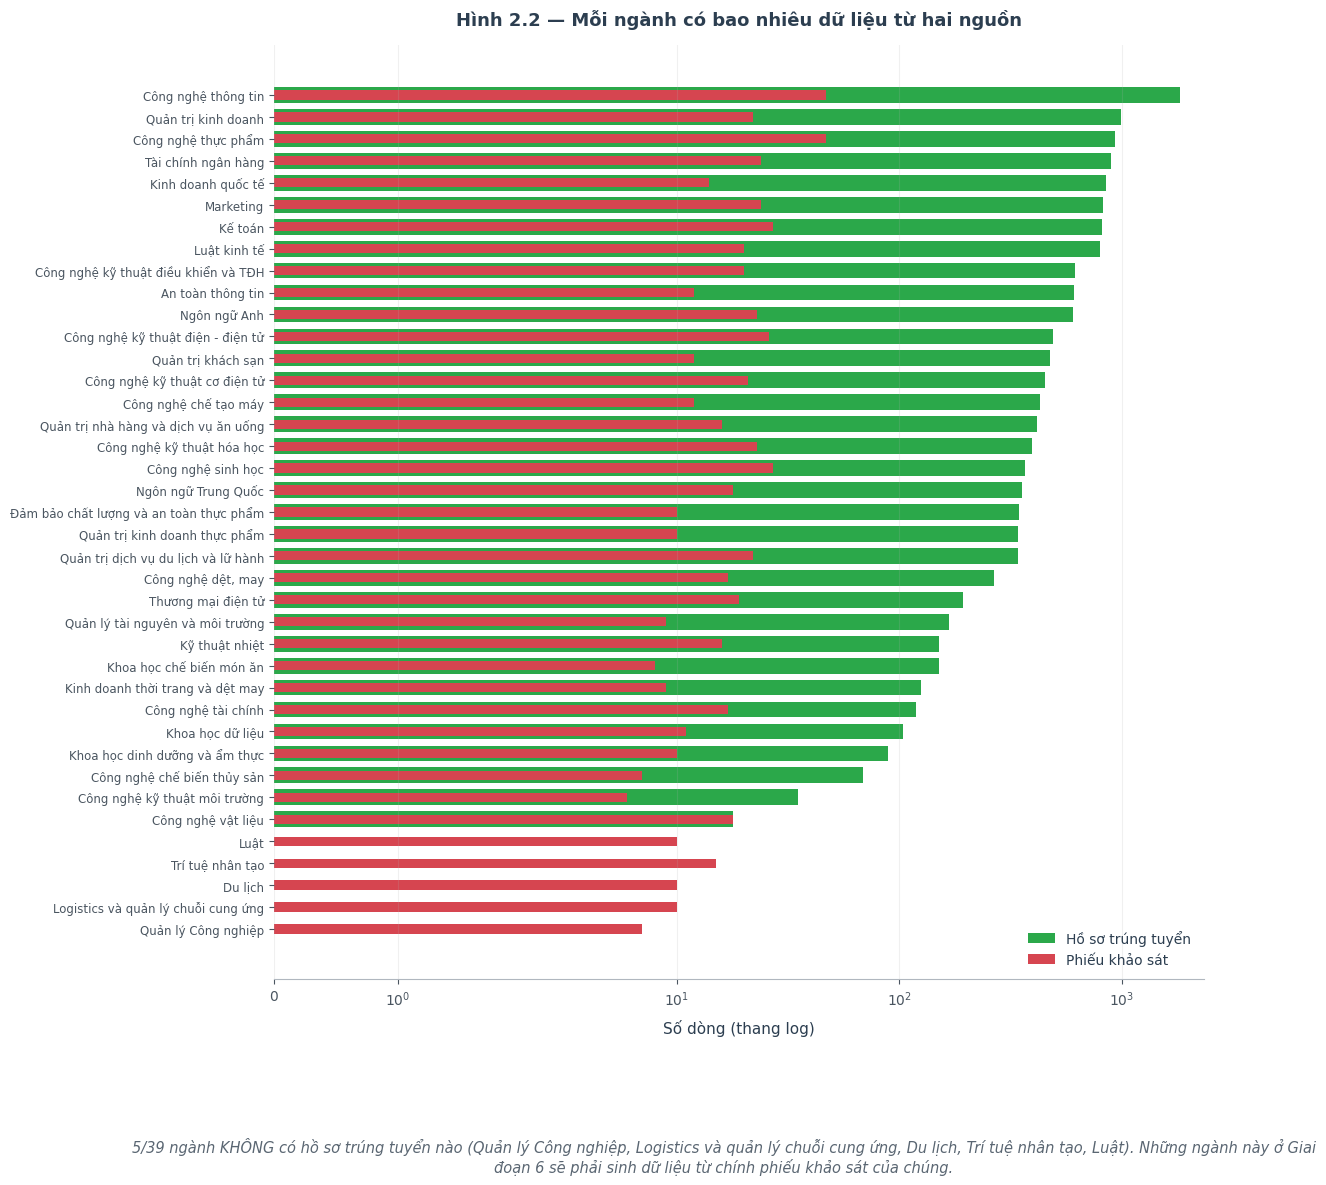

In [5]:
# ═══════════ HÌNH 2.2 — Độ phủ theo ngành ═══════════
co_tt = d.ma_nganh.value_counts()
co_ks = ks.ma_nganh.value_counts()
dp = pd.DataFrame({"ttth": co_tt, "khaosat": co_ks}).fillna(0).astype(int)
dp["nganh"] = [MA_TO_TEN[m] for m in dp.index]
dp["nhom"] = [TEN_NHOM[NHOM[m]] for m in dp.index]
dp = dp.sort_values("ttth")
dp.to_csv(OUT / "do_phu_theo_nganh.csv")

fig, ax = plt.subplots(figsize=(12, cao_theo_dong(len(dp))))
yy = np.arange(len(dp))
ax.barh(yy, dp.ttth, color=C_GA, height=.72, label="Hồ sơ trúng tuyển")
ax.barh(yy, dp.khaosat, color=C_THAT, height=.42, label="Phiếu khảo sát")
ax.set_yticks(yy); ax.set_yticklabels(list(dp.nganh), fontsize=8.5)
ax.set_xlabel("Số dòng (thang log)"); ax.set_xscale("symlog")
ax.set_title("Hình 2.2 — Mỗi ngành có bao nhiêu dữ liệu từ hai nguồn")
cho_chu_giai(ax, phan=.22)
ax.legend(loc="lower right", framealpha=.95)
ax.grid(axis="y", alpha=0)
thieu = dp[dp.ttth == 0]
luu(fig, OUT, "hinh_2_2_do_phu.png",
    f"{len(thieu)}/39 ngành KHÔNG có hồ sơ trúng tuyển nào"
    + (f" ({', '.join(thieu.nganh.head(6))})" if len(thieu) else "")
    + ". Những ngành này ở Giai đoạn 6 sẽ phải sinh dữ liệu từ chính phiếu khảo sát của chúng.")
plt.show()

   💾 hinh_2_3_to_hop_diem.png


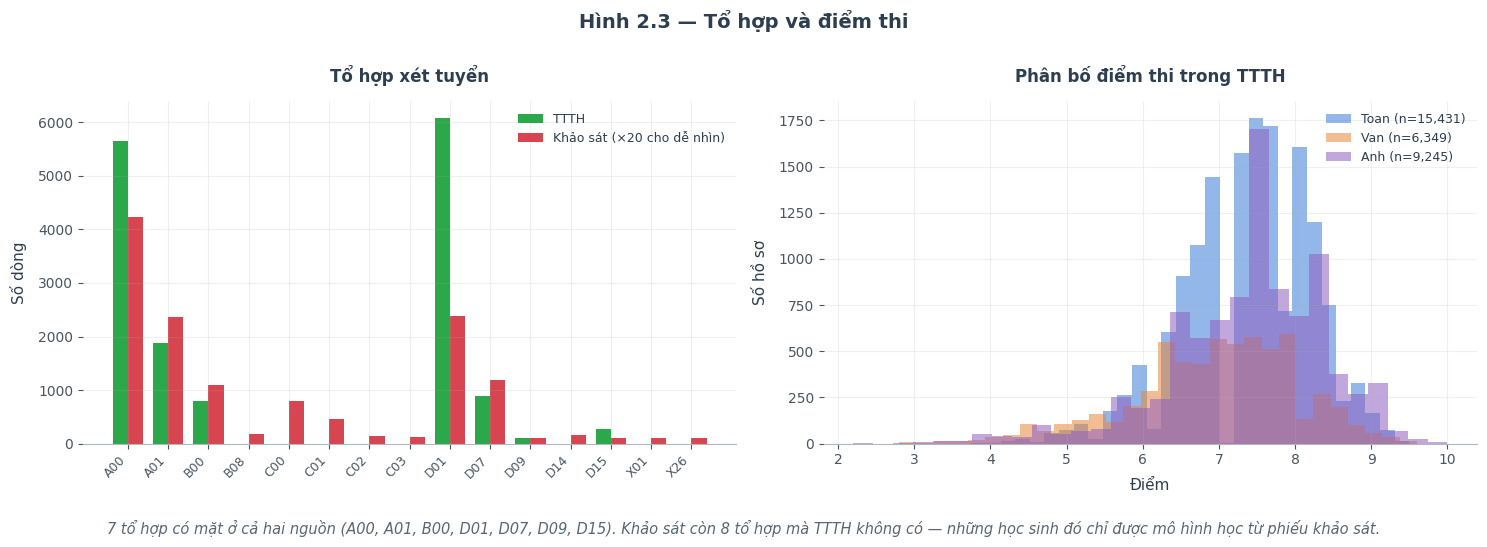

In [6]:
# ═══════════ HÌNH 2.3 — Điểm và tổ hợp ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
th_tt = d.to_hop_thi.value_counts()
th_ks = ks.to_hop_thi.str.split(" ").str[0].value_counts()
moi = sorted(set(th_tt.index) | set(th_ks.index))
x = np.arange(len(moi)); w = .38
a1.bar(x - w/2, [th_tt.get(t, 0) for t in moi], w, color=C_GA, label="TTTH")
a1.bar(x + w/2, [th_ks.get(t, 0) * 20 for t in moi], w, color=C_THAT,
       label="Khảo sát (×20 cho dễ nhìn)")
a1.set_xticks(x); a1.set_xticklabels(moi, rotation=45, ha="right", fontsize=9)
a1.set_ylabel("Số dòng"); a1.set_title("Tổ hợp xét tuyển", fontsize=12); a1.legend(fontsize=9)

for c, mau in zip(["diem_Toan", "diem_Van", "diem_Anh"], [C_XANH, C_CAM, C_TIM]):
    v = d[c].dropna()
    if len(v) > 50:
        a2.hist(v, bins=30, alpha=.55, color=mau, label=f"{c.replace('diem_','')} (n={len(v):,})")
a2.set_xlabel("Điểm"); a2.set_ylabel("Số hồ sơ")
a2.set_title("Phân bố điểm thi trong TTTH", fontsize=12); a2.legend(fontsize=9)

fig.suptitle("Hình 2.3 — Tổ hợp và điểm thi", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
chung = sorted(set(th_tt.index) & set(th_ks.index))
luu(fig, OUT, "hinh_2_3_to_hop_diem.png",
    f"{len(chung)} tổ hợp có mặt ở cả hai nguồn ({', '.join(chung)}). Khảo sát còn "
    f"{len(set(th_ks.index)-set(th_tt.index))} tổ hợp mà TTTH không có — những học sinh đó chỉ "
    "được mô hình học từ phiếu khảo sát.")
plt.show()

   💾 hinh_2_4_so_diem.png

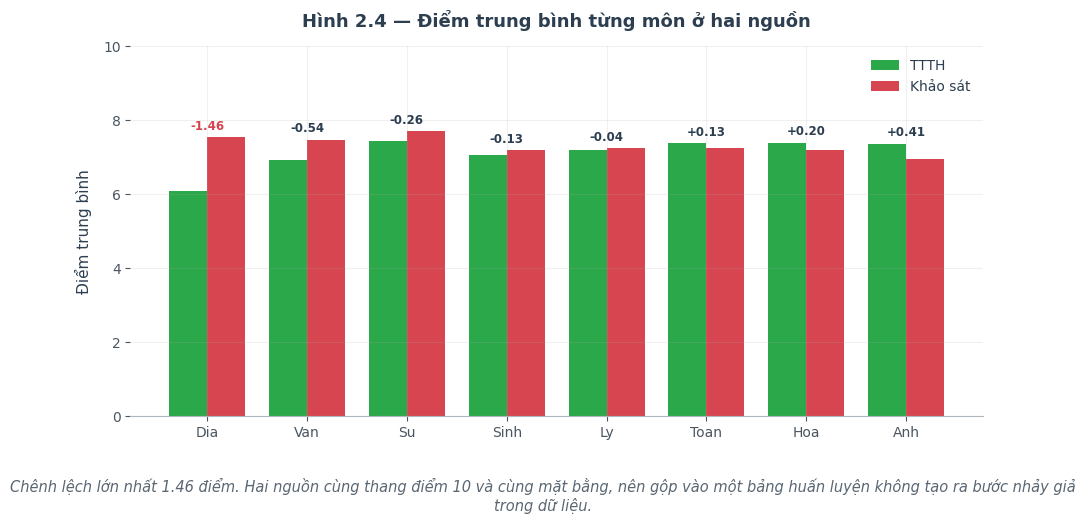

In [7]:
# ═══════════ HÌNH 2.4 — So điểm hai nguồn ═══════════
fig, ax = plt.subplots(figsize=(11, 4.8))
x = np.arange(len(ss)); w = .38
ax.bar(x - w/2, ss.ttth_tb, w, color=C_GA, label="TTTH")
ax.bar(x + w/2, ss.ks_tb, w, color=C_THAT, label="Khảo sát")
ax.set_xticks(x); ax.set_xticklabels(ss.mon, fontsize=10)
ax.set_ylabel("Điểm trung bình"); ax.set_ylim(0, 10)
ax.set_title("Hình 2.4 — Điểm trung bình từng môn ở hai nguồn"); ax.legend()
for i, r in enumerate(ss.itertuples()):
    ax.text(i, max(r.ttth_tb, r.ks_tb) + .2, f"{r.chenh:+.2f}", ha="center",
            fontsize=8.5, fontweight="bold",
            color=C_THAT if abs(r.chenh) > 1 else C_DAM)
luu(fig, OUT, "hinh_2_4_so_diem.png",
    f"Chênh lệch lớn nhất {ss.chenh.abs().max():.2f} điểm. Hai nguồn cùng thang điểm 10 và cùng "
    "mặt bằng, nên gộp vào một bảng huấn luyện không tạo ra bước nhảy giả trong dữ liệu.")
plt.show()

## 3. Xuất dữ liệu

In [8]:
giu = ["SBD", "ma_nganh", "to_hop_thi"] + C_DIEM
d["ma_nhom"] = d.ma_nganh.map(NHOM)
d[giu + ["ma_nhom"]].to_csv(OUT / "ttth_sach.csv", index=False)

tom_tat("GIAI ĐOẠN 2 — CHUẨN BỊ HỒ SƠ TRÚNG TUYỂN", [
    f"Hồ sơ trong file       {buoc[0][1]:,}",
    f"Hồ sơ dùng được        {len(d):,}   ({len(d)/buoc[0][1]:.0%})",
    f"   không trúng tuyển   {buoc[0][1]-buoc[1][1]:,}",
    f"   mã ngành ngoài 39   {buoc[1][1]-buoc[2][1]:,}",
    f"   tổ hợp D10          {buoc[2][1]-buoc[3][1]:,}",
    f"   SBD trùng           {n_trung}",
    "",
    f"Ngành có hồ sơ         {d.ma_nganh.nunique()}/39"
    f"   (thiếu {39-d.ma_nganh.nunique()} ngành)",
    f"Tổ hợp                 {d.to_hop_thi.nunique()}   {sorted(d.to_hop_thi.unique())}",
    f"Điểm                   mỗi hồ sơ đúng 3 môn, cùng thang với khảo sát",
    "",
    "Nguồn này KHÔNG có: 10 câu Likert · giới tính · mục tiêu nghề nghiệp",
    "   → Giai đoạn 6 sẽ dùng GA sinh 3 nhóm cột đó",
])
print(f"\n✅ ttth_sach.csv · do_phu_theo_nganh.csv · 4 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                  GIAI ĐOẠN 2 — CHUẨN BỊ HỒ SƠ TRÚNG TUYỂN                  ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Hồ sơ trong file       18,024                                              ║
║ Hồ sơ dùng được        15,696   (87%)                                      ║
║    không trúng tuyển   752                                                 ║
║    mã ngành ngoài 39   373                                                 ║
║    tổ hợp D10          963                                                 ║
║    SBD trùng           240                                                 ║
║                                                                            ║
║ Ngành có hồ sơ         34/39   (thiếu 5 ngành)                             ║
║ Tổ hợp                 7   ['A00', 'A01', 'B00', 'D01', 'D07', 'D09', 'D15 ║
║ Điểm                   mỗi hồ sơ đúng 3 môn, cùng 